# Boresch anchor point selection

This notebook contains code for visualising the ternary complex RMSF and select protein CA anchor points based on RMSF stability.

In [ ]:
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt
from MDAnalysis.analysis.distances import dist
from tqdm import tqdm
import pandas as pd
import pickle
import red
import yaml

/home/btan/miniconda3/envs/openbiosim/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


### Functions for reading in RMSF csv files

In [ ]:
def obtain_RMSF(run_number, species='complex'):

    if species == 'complex':
        filename = 'RMSF.csv'
    elif species == 'ligand':
        filename = 'RMSF_ligand.csv'
    else:
        filename = 'RMSF_receptor.csv'

    df = pd.read_csv(f"results/run{run_number}/{filename}")

    residx = df['Residue index'].to_numpy()
    RMSF = df['RMSF (Angstrom)'].to_numpy()

    return residx, RMSF

In [21]:
def obtain_av_RMSF(run_numbers, species='complex'):

    RMSFs = []

    for run_number in run_numbers:

        res, rmsf = obtain_RMSF(run_number, species)
        RMSFs.append(rmsf)

    RMSFs = np.array(RMSFs)

    return res, np.average(RMSFs, axis=0), np.std(RMSFs, axis=0)
        

In [22]:
def obtain_CA_idx(u, res_idx):
    """Function to obtain the index of the alpha carbon for a given residue index"""
    
    selection_str = f"protein and resid {res_idx} and name CA"
    
    selected_CA = u.select_atoms(selection_str)

    if len(selected_CA.indices) == 0:
        print('CA not found for the specified residue...')
    
    elif len(selected_CA.indices) > 1:
        print('Multiple CAs found, uh oh...')

    else:  
        return selected_CA.indices[0]

In [23]:
def obtain_distance(pos1, pos2):
    
    return np.linalg.norm(pos1 - pos2)

In [24]:
def obtain_angle(pos1, pos2, pos3):

    return mda.lib.distances.calc_angles(pos1, pos2, pos3)

In [25]:
def obtain_dihedral(pos1, pos2, pos3, pos4):
    
    return mda.lib.distances.calc_dihedrals(pos1, pos2, pos3, pos4)

### Plotting RMSF

Text(0, 0.5, 'Average RMSF (Å)')

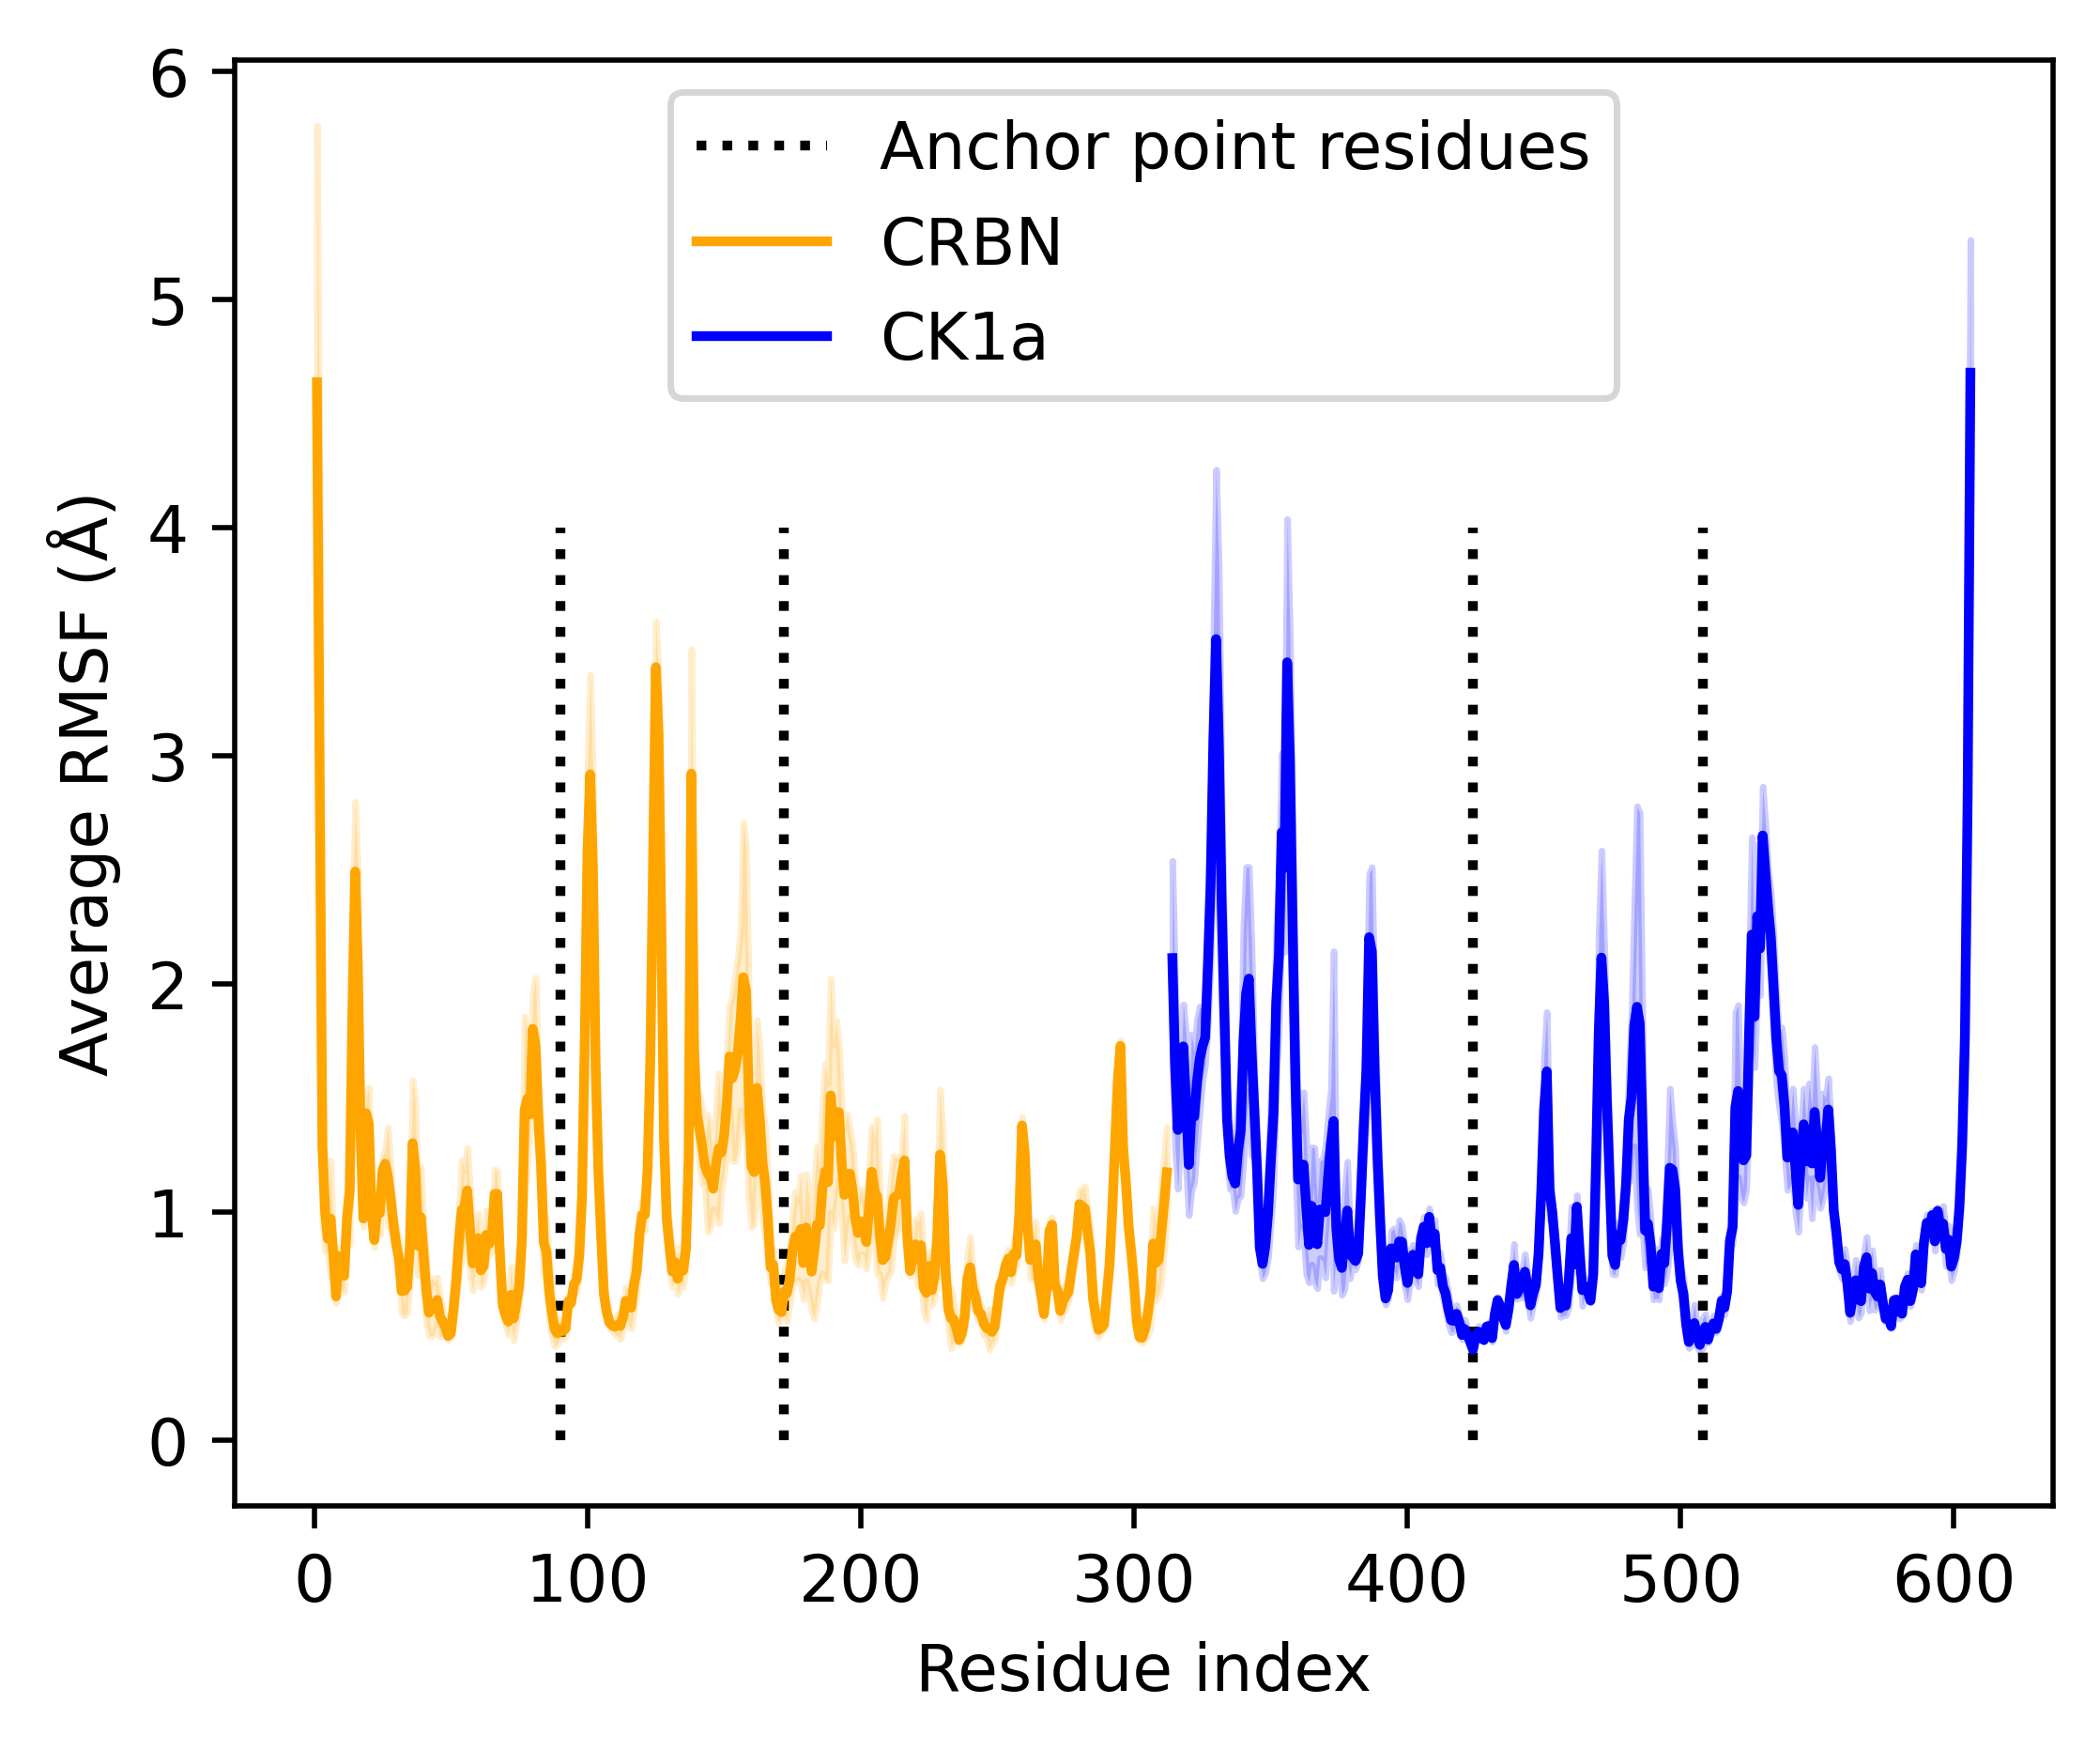

In [ ]:
# Declare trial anchor points
res_b = FIXME 
res_c = FIXME 
res_B = FIXME 
res_C = FIXME

runs = [1,2,3]

res_receptor, av_RMSF_receptor, std_RMSF_receptor= obtain_av_RMSF(runs, species='receptor')
res_ligand, av_RMSF_ligand, std_RMSF_ligand= obtain_av_RMSF(runs, species='ligand')

plt.figure(figsize=(5,4), dpi=500)
plt.vlines([res_b, res_c,  res_B, res_C], ymin=4*[0], ymax=4*[max(np.append(av_RMSF_receptor, av_RMSF_ligand))], colors='k', linestyles='dotted', label='Anchor point residues')
plt.plot(res_receptor, av_RMSF_receptor, c='orange', label='receptor')
plt.fill_between(res_receptor, av_RMSF_receptor-std_RMSF_receptor, av_RMSF_receptor+std_RMSF_receptor, color='orange', alpha=0.2)
plt.plot(res_ligand, av_RMSF_ligand, c='blue', label='ligand')
plt.fill_between(res_ligand, av_RMSF_ligand-std_RMSF_ligand, av_RMSF_ligand+std_RMSF_ligand, color='blue', alpha=0.2)
plt.legend()
plt.xlabel('Residue index')
plt.ylabel('Average RMSF (Å)')

# Update config.yaml
with open('config.yaml', 'r') as infile:
    data = yaml.safe_load(infile)

data['Boresch anchor points']['res_b'] = res_b
data['Boresch anchor points']['res_c'] = res_c
data['Boresch anchor points']['res_B'] = res_B
data['Boresch anchor points']['res_C'] = res_C

with open('config.yaml', 'w') as outfile:
    yaml.safe_dump(data, outfile)